In [14]:
pip install arch

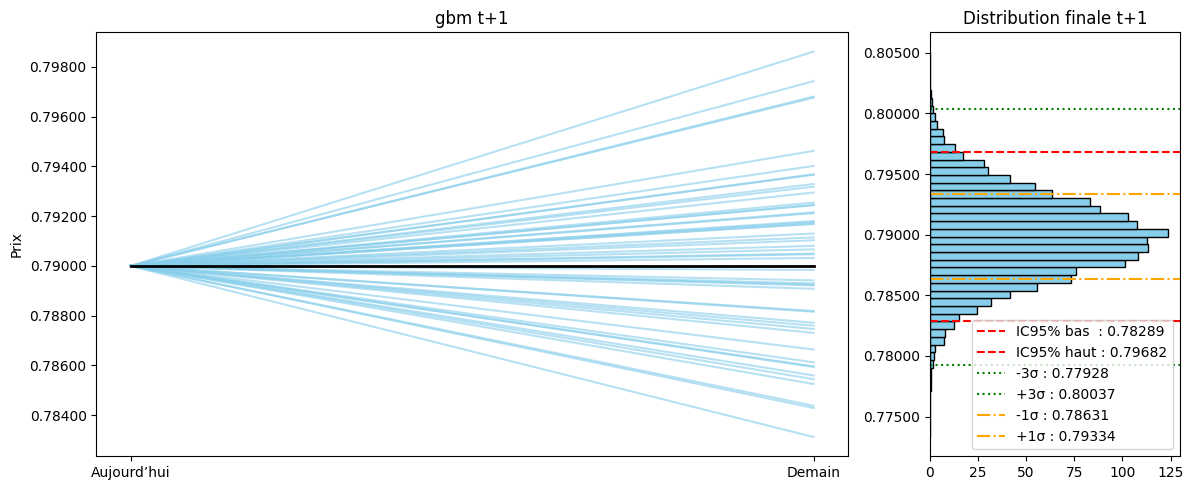

100%|██████████| 50/50 [01:02<00:00,  1.24s/it]


Couverture 95%  : 94.00%
Couverture 99.7%: 98.00%
Largeur moyenne IC95 : 0.02
Score de Winkler moyen: 0.02


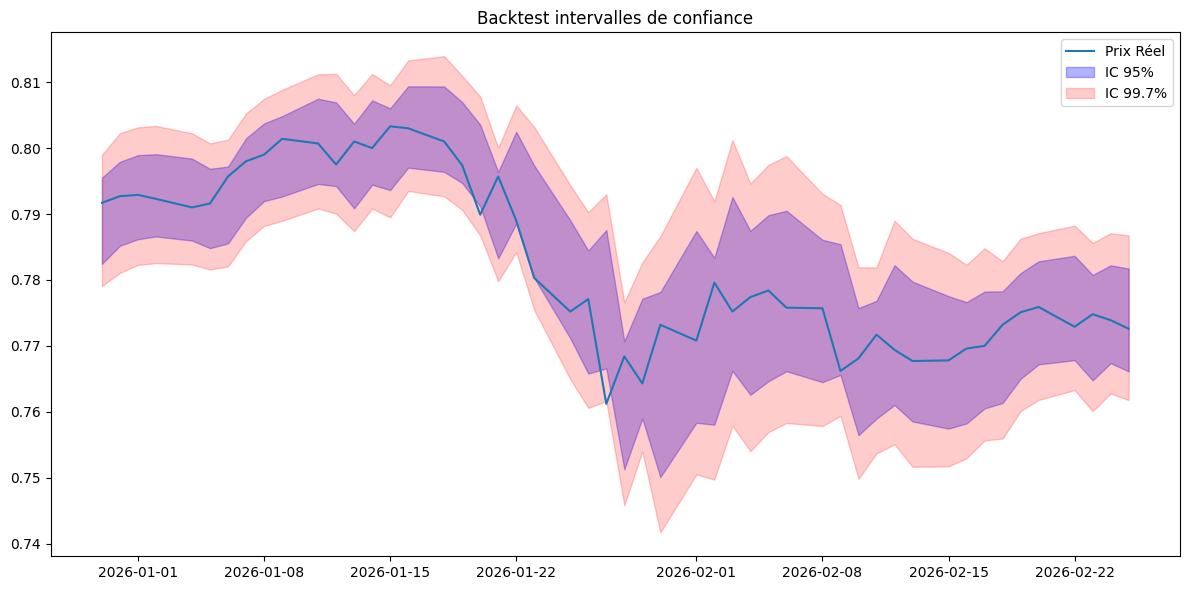

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FormatStrFormatter
import requests
from datetime import datetime, timedelta
import scipy.stats as stats
from arch import arch_model
from tqdm import tqdm

def get_daily_data(symbol, start_date, end_date, api_token):
    url = (
        f'https://eodhd.com/api/eod/{symbol}'
        f'?api_token={api_token}&from={start_date}&to={end_date}&fmt=json'
    )
    r = requests.get(url, timeout=10)
    if r.status_code != 200:
        raise RuntimeError(f"Erreur {r.status_code}")
    df = pd.DataFrame(r.json())
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)
    return df['adjusted_close'].sort_index()

api_token = '68efdceed38ec8.15967744'
symbol    = 'USDCHF.FOREX'
end_date  = datetime.now().strftime('%Y-%m-%d')
start_date= (datetime.now() - timedelta(days=365*10)).strftime('%Y-%m-%d')
prices    = get_daily_data(symbol, start_date, end_date, api_token)


np.random.seed(42)
log_ret  = np.log(prices / prices.shift(1)).dropna()
mu_daily = log_ret.mean()
S0       = prices.iloc[-1]
dt       = 1
n_sims   = 10_000
n_days   = 1

am   = arch_model(log_ret * 100, vol='FIGARCH', p=1, o=0, q=1, dist='studentst')
res  = am.fit(disp='off')
sigma_fig = res.conditional_volatility / 100
resid      = (log_ret * 100 - res.params['mu']) / res.conditional_volatility
nu         = max(4, stats.t.fit(resid, floc=0, fscale=1)[0])

def rolling_entropy(x, window=60, bins=20):
    def ent(v):
        p, _ = np.histogram(v, bins=bins, density=True)
        p = p[p > 0]
        return -np.sum(p * np.log(p))
    return x.rolling(window).apply(ent, raw=True)

H_series = rolling_entropy(resid)
M_series = log_ret.abs().rolling(60).mean()
h_star   = H_series.quantile(0.95)
m_star   = M_series.quantile(0.95)
bar_sigma2 = (sigma_fig**2).mean()
redundancy  = 1 + 0.1 * np.log1p(prices.rolling(5).var() / prices.rolling(20).var())
info_filter = (H_series > H_series.mean()).astype(float)
H_max, M_max = H_series.max(), M_series.max()
α0, δ0 = 0.5, 0.3
if α0 * H_max + δ0 * M_max >= 1:
    fac = 0.95 / (α0 * H_max + δ0 * M_max)
    α0 *= fac
    δ0 *= fac
base_params = {'alpha': α0, 'delta': δ0, 'gamma': 0.2, 'kappa': 0.1, 'eta': 1e-3}

def update_params(p, sigma2, bar_sigma2, t):
    err = sigma2 - bar_sigma2
    lr  = p['eta'] / (1 + t**0.55)
    p['gamma'] = np.clip(p['gamma'] + lr * err, 0.01, 0.5)
    return p

def simulate_cyber_gbm(S0, mu, sigma_fig, H, M,
                       params, bar_sigma2, n_steps, dt=1, eps=1e-6):
    S = np.zeros(n_steps + 1)
    V = np.zeros(n_steps + 1)
    S[0] = S0
    sigma2 = sigma_fig.iloc[-1] ** 2
    H_max = H.max() if H.max() > 0 else 1.0
    M_max = M.max() if M.max() > 0 else 1.0
    for t in range(1, n_steps + 1):
        current = -1
        H_val = min(H.iloc[current] / H_max, 1.0)
        M_val = min(M.iloc[current] / M_max, 1.0)
        crisis  = (H_val > 0.8) or (M_val > 0.8)
        delta_t = params['delta'] if crisis else 0.0
        sigma2 = (
            sigma_fig.iloc[current]**2 * (1 + params['alpha'] * H_val + delta_t * M_val)
            + params['gamma'] * (bar_sigma2 - sigma2)
        )
        sigma2 *= max(1e-12, redundancy.iloc[current])
        sigma2 *= 1 + 0.5 * info_filter.iloc[current]
        sigma2 = max(eps, min(sigma2, 0.5))
        Z   = np.random.standard_t(nu) * np.sqrt((nu - 2) / nu)
        S[t]= S[t-1] * np.exp((mu - 0.5 * sigma2) * dt + np.sqrt(sigma2 * dt) * Z)
        V[t]= sigma2
        params = update_params(params, sigma2, bar_sigma2, t)
    return S, V

def simulate_mc(S0, mu, sigma_fig, H, M, bar_sigma2,
                n_sims=10_000, n_days=1):
    out = np.zeros((n_sims, n_days + 1))
    for i in range(n_sims):
        paths, _ = simulate_cyber_gbm(
            S0, mu, sigma_fig, H, M,
            base_params.copy(),
            bar_sigma2, n_days, dt
        )
        out[i] = paths
    return out

paths = simulate_mc(S0, mu_daily, sigma_fig, H_series, M_series,
                    bar_sigma2, n_sims, n_days)

S_t1    = paths[:, 1]
low_t1, high_t1 = np.percentile(S_t1, [2.5, 97.5])
mean_t1, std_t1 = S_t1.mean(), S_t1.std(ddof=0)
minus3, plus3   = mean_t1 - 3 * std_t1, mean_t1 + 3 * std_t1
minus1, plus1   = mean_t1 - std_t1,     mean_t1 + std_t1

fig = plt.figure(figsize=(12, 5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[3, 1])

ax0 = fig.add_subplot(gs[0])
x   = [0, 1]
for i in np.random.choice(len(S_t1), 50, False):
    ax0.plot(x, [S0, S_t1[i]], color='skyblue', alpha=0.6)
ax0.plot(x, [S0, S0], color='black', lw=2)
ax0.set_xticks(x)
ax0.set_xticklabels(['Aujourd’hui', 'Demain'])
ax0.set_title("gbm t+1")
ax0.set_ylabel("Prix")
ax0.yaxis.set_major_formatter(FormatStrFormatter('%.5f'))

ax1 = fig.add_subplot(gs[1])
ax1.hist(S_t1, bins=50, orientation='horizontal', density=True,
         color='skyblue', edgecolor='black')
ax1.axhline(low_t1,   color='red',    ls='--', label=f"IC95% bas  : {low_t1:.5f}")
ax1.axhline(high_t1,  color='red',    ls='--', label=f"IC95% haut : {high_t1:.5f}")
ax1.axhline(minus3,   color='green',  ls=':',  label=f"-3σ : {minus3:.5f}")
ax1.axhline(plus3,    color='green',  ls=':',  label=f"+3σ : {plus3:.5f}")
ax1.axhline(minus1,   color='orange', ls='-.', label=f"-1σ : {minus1:.5f}")  # -1σ
ax1.axhline(plus1,    color='orange', ls='-.', label=f"+1σ : {plus1:.5f}")   # +1σ
ax1.set_title("Distribution finale t+1")
ax1.legend(loc='lower right')
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.5f'))
plt.tight_layout()
plt.show()

# backtest (inchangé, sans ±1σ)
def backtest_confidence_intervals(prices, train=504, test=252):
    log_ret = np.log(prices / prices.shift(1)).dropna()
    res_li  = []
    for i in tqdm(range(train, train + test)):
        train_ret = log_ret.iloc[i - train:i]
        am  = arch_model(train_ret * 100, vol='FIGARCH',
                         p=1, o=0, q=1, dist='studentst')
        res = am.fit(disp='off')
        sigma_fig = res.conditional_volatility / 100
        resid = (train_ret * 100 - res.params['mu']) / res.conditional_volatility
        nu_bt = max(4, stats.t.fit(resid, floc=0, fscale=1)[0])
        H_bt = rolling_entropy(resid).iloc[:-1]
        M_bt = train_ret.abs().rolling(60).mean().iloc[:-1]
        sigma_bt = sigma_fig.iloc[:-1]
        bar_sigma2_bt = (sigma_bt**2).mean()
        S0_bt = prices.iloc[i]
        paths_bt = simulate_mc(S0_bt, train_ret.mean(),
                               sigma_bt, H_bt, M_bt,
                               bar_sigma2_bt,
                               n_sims=10_000, n_days=1)
        S_t1 = paths_bt[:, 1]
        low95, high95 = np.percentile(S_t1, [2.5, 97.5])
        low997, high997 = np.percentile(S_t1, [0.15, 99.85])
        actual = prices.iloc[i + 1]
        width95  = high95 - low95
        width997 = high997 - low997
        alpha = 0.05
        winkler = (width95 + (2/alpha)*(low95-actual)) if actual < low95 else \
                  (width95 + (2/alpha)*(actual-high95)) if actual > high95 else \
                  width95
        res_li.append({
            'date': prices.index[i + 1],
            'actual': actual,
            'low_95': low95, 'high_95': high95,
            'low_997': low997, 'high_997': high997,
            'coverage_95': int(low95 <= actual <= high95),
            'coverage_997': int(low997 <= actual <= high997),
            'width_95': width95,
            'width_997': width997,
            'winkler': winkler
        })

    return pd.DataFrame(res_li)

results_df = backtest_confidence_intervals(
    prices,
    train=200,
    test=50
)
print(f"Couverture 95%  : {results_df['coverage_95'].mean():.2%}")
print(f"Couverture 99.7%: {results_df['coverage_997'].mean():.2%}")
print(f"Largeur moyenne IC95 : {results_df['width_95'].mean():.2f}")
print(f"Score de Winkler moyen: {results_df['winkler'].mean():.2f}")

plt.figure(figsize=(12, 6))
plt.plot(results_df['date'], results_df['actual'], label='Prix Réel')
plt.fill_between(results_df['date'], results_df['low_95'],  results_df['high_95'],
                 alpha=0.3, color='blue', label='IC 95%')
plt.fill_between(results_df['date'], results_df['low_997'], results_df['high_997'],
                 alpha=0.2, color='red', label='IC 99.7%')
plt.legend()
plt.title("Backtest intervalles de confiance")
plt.tight_layout()
plt.show()



STRATÉGIE OPTIONS POUR USDCHF.FOREX

► Paramètres optimaux calculés:
  - Durée optimale: 60 jours
  - Strike Put: 0.74918 (Théorique: 0.00038, Marché: 0.00036, Ratio: 0.95)
  - Strike Call: 0.82266 (Théorique: 0.00048, Marché: 0.00050, Ratio: 1.05)
  - Prime totale: 0.00085 (Marché: 0.00086, Ratio: 1.00)
  - Risque (VaR 95%): 0.00591
  - Ratio Prime/Risque: 0.14

► Grecques Put (0.74918):
  - Delta: 0.0000  Gamma: 0.0000
  - Vega: -0.0377  Theta: -0.0000

► Grecques Call (0.82266):
  - Delta: 0.0000  Gamma: 0.0000
  - Vega: 0.0425  Theta: -0.0000

► Recommandation de trading:
  → NE PAS INTERVENIR (options fair value)



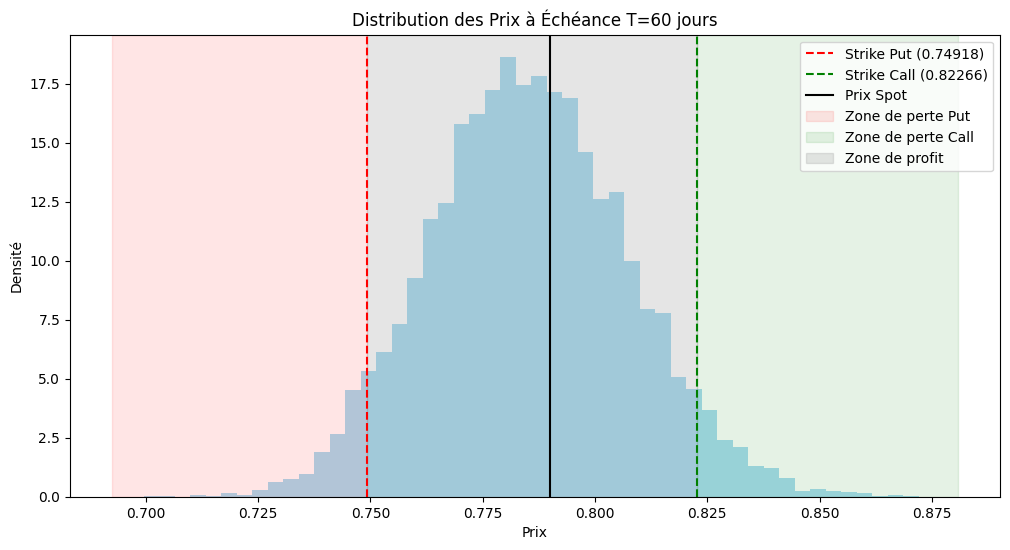

In [16]:
def theoretical_option_price(S0, K, T, r, paths, option_type, is_cyber=True):
    t_index = int(T * 252)
    if is_cyber:
        ST = paths[:, t_index]
    else:
        ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*np.random.randn(len(paths)))
    if option_type == 'call':
        payoff = np.maximum(ST - K, 0)
    else:
        payoff = np.maximum(K - ST, 0)
    return np.exp(-r * T) * np.mean(payoff)

def optimal_strikes(paths, S0, T, prob=0.05):
    t_index = int(T * 252)
    future_prices = paths[:, t_index]
    K_put = np.percentile(future_prices, prob * 100)
    K_call = np.percentile(future_prices, 100 - prob * 100)
    put_adj = (S0 - K_put) / S0
    call_adj = (K_call - S0) / S0

    return K_put, K_call, put_adj, call_adj

def calculate_greeks(S0, K, T, r, paths, option_type, epsilon=0.01):
    base_price = theoretical_option_price(S0, K, T, r, paths, option_type)
    price_up = theoretical_option_price(S0*(1+epsilon), K, T, r, paths, option_type)
    price_down = theoretical_option_price(S0*(1-epsilon), K, T, r, paths, option_type)
    delta = (price_up - price_down) / (2 * epsilon * S0)
    gamma = (price_up - 2*base_price + price_down) / ((epsilon * S0)**2)
    vega = (theoretical_option_price(S0, K, T, r, paths*(1+epsilon), option_type) -
            theoretical_option_price(S0, K, T, r, paths*(1-epsilon), option_type)) / (2 * epsilon)
    T_small = max(T - 1/252, 0.001)
    theta = (theoretical_option_price(S0, K, T_small, r, paths, option_type) - base_price)

    return {
        'delta': delta,
        'gamma': gamma,
        'vega': vega,
        'theta': theta
    }

def optimal_duration(paths, S0, r, strike_prob=0.05):
    durations = np.array([7, 14, 21, 30, 45, 60]) / 365
    results = []

    for T in durations:
        K_put, K_call, _, _ = optimal_strikes(paths, S0, T, strike_prob)
        put_price = theoretical_option_price(S0, K_put, T, r, paths, 'put')
        call_price = theoretical_option_price(S0, K_call, T, r, paths, 'call')
        total_premium = put_price + call_price
        t_index = int(T * 252)
        future_prices = paths[:, t_index]
        put_payoff = np.maximum(K_put - future_prices, 0)
        call_payoff = np.maximum(future_prices - K_call, 0)
        total_payoff = put_payoff + call_payoff
        var_95 = np.percentile(total_payoff, 95)
        if var_95 > 0:
            ratio = total_premium / var_95
            results.append((T, ratio, total_premium, var_95, K_put, K_call))

    if not results:
        return None, None

    best_duration = max(results, key=lambda x: x[1])[0]
    best_details = next(x for x in results if x[0] == best_duration)
    return best_duration, best_details

r = 0.05
n_days_options = 60
paths_options = simulate_mc(S0, mu_daily, sigma_fig, H_series, M_series,
                            bar_sigma2, n_sims, n_days_options)
best_T, best_details = optimal_duration(paths_options, S0, r)
T_days = int(best_T * 365)
K_put, K_call = best_details[4], best_details[5]
total_premium = best_details[2]
var_95 = best_details[3]
theoretical_put = theoretical_option_price(S0, K_put, best_T, r, paths_options, 'put')
theoretical_call = theoretical_option_price(S0, K_call, best_T, r, paths_options, 'call')
greeks_put = calculate_greeks(S0, K_put, best_T, r, paths_options, 'put')
greeks_call = calculate_greeks(S0, K_call, best_T, r, paths_options, 'call')


def fetch_market_options_data(symbol, expiration_date):
    strikes = np.linspace(K_put * 0.98, K_call * 1.02, 20)
    data = {
        'strike': strikes,
        'call_price': [theoretical_call * (0.9 + 0.2*np.random.rand()) for _ in strikes],
        'put_price': [theoretical_put * (0.9 + 0.2*np.random.rand()) for _ in strikes],
        'call_delta': [greeks_call['delta'] * (0.95 + 0.1*np.random.rand()) for _ in strikes],
        'put_delta': [greeks_put['delta'] * (0.95 + 0.1*np.random.rand()) for _ in strikes],
    }
    return pd.DataFrame(data)
expiration_date = (datetime.now() + timedelta(days=T_days)).strftime('%Y-%m-%d')
options_data = fetch_market_options_data(symbol, expiration_date)
put_data = options_data.iloc[(options_data['strike'] - K_put).abs().argsort()[:1]]
call_data = options_data.iloc[(options_data['strike'] - K_call).abs().argsort()[:1]]
market_put = put_data['put_price'].values[0]
market_call = call_data['call_price'].values[0]
market_total = market_put + market_call
put_ratio = market_put / theoretical_put
call_ratio = market_call / theoretical_call
total_ratio = market_total / total_premium
is_expensive = total_ratio > 1.15
is_cheap = total_ratio < 0.85



print(f"\n{'='*50}")
print(f"STRATÉGIE OPTIONS POUR {symbol}")
print(f"{'='*50}\n")
print(f"► Paramètres optimaux calculés:")
print(f"  - Durée optimale: {T_days} jours")
print(f"  - Strike Put: {K_put:.5f} (Théorique: {theoretical_put:.5f}, Marché: {market_put:.5f}, Ratio: {put_ratio:.2f})")
print(f"  - Strike Call: {K_call:.5f} (Théorique: {theoretical_call:.5f}, Marché: {market_call:.5f}, Ratio: {call_ratio:.2f})")
print(f"  - Prime totale: {total_premium:.5f} (Marché: {market_total:.5f}, Ratio: {total_ratio:.2f})")
print(f"  - Risque (VaR 95%): {var_95:.5f}")
print(f"  - Ratio Prime/Risque: {total_premium/var_95:.2f}\n")
print(f"► Grecques Put ({K_put:.5f}):")
print(f"  - Delta: {greeks_put['delta']:.4f}  Gamma: {greeks_put['gamma']:.4f}")
print(f"  - Vega: {greeks_put['vega']:.4f}  Theta: {greeks_put['theta']:.4f}\n")
print(f"► Grecques Call ({K_call:.5f}):")
print(f"  - Delta: {greeks_call['delta']:.4f}  Gamma: {greeks_call['gamma']:.4f}")
print(f"  - Vega: {greeks_call['vega']:.4f}  Theta: {greeks_call['theta']:.4f}\n")
print(f"► Recommandation de trading:")
if is_cheap:
    print("  → ACHETER le strangle (options sous-évaluées)")
elif is_expensive:
    print("  → VENDRE le strangle (options surévaluées)")
else:
    print("  → NE PAS INTERVENIR (options fair value)")

print(f"\n{'='*50}")


def plot_option_strategy(paths, S0, K_put, K_call, T):
    t_index = int(T * 252)
    future_prices = paths[:, t_index]
    plt.figure(figsize=(12, 6))
    plt.hist(future_prices, bins=50, alpha=0.7, density=True, color='skyblue')
    plt.axvline(K_put, color='red', linestyle='--', label=f'Strike Put ({K_put:.5f})')
    plt.axvline(K_call, color='green', linestyle='--', label=f'Strike Call ({K_call:.5f})')
    plt.axvline(S0, color='black', label='Prix Spot')
    plt.axvspan(min(future_prices)*0.99, K_put, color='red', alpha=0.1, label='Zone de perte Put')
    plt.axvspan(K_call, max(future_prices)*1.01, color='green', alpha=0.1, label='Zone de perte Call')
    plt.axvspan(K_put, K_call, color='grey', alpha=0.2, label='Zone de profit')
    plt.title(f"Distribution des Prix à Échéance T={T*365:.0f} jours")
    plt.xlabel("Prix")
    plt.ylabel("Densité")
    plt.legend()
    plt.show()
plot_option_strategy(paths_options, S0, K_put, K_call, best_T)